In [937]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [938]:
df = pd.read_csv("/content/Social_Network_Ads (1).csv")

In [939]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [940]:
df1 = df.drop(columns=["User ID","Gender"],axis=1)

In [941]:
df1.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [942]:
X_train,X_test,y_train,y_test = train_test_split(df1.drop("Purchased",axis =1),
                                                 df1["Purchased"],test_size=0.3,random_state=0)

In [943]:
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [944]:
X_test.head()

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000


In [945]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [946]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [947]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [948]:
X_train_scaled.head()

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


In [949]:
X_test_scaled.head()

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804


In [950]:
X_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


In [951]:
round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


In [952]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [953]:
X_test_scaled.describe()

,Age,EstimatedSalary
count,120.000000,120.000000
mean,-0.068394,-0.006231
std,1.088712,0.952412
min,-1.947491,-1.584970
25%,-0.967093,-0.659561
50%,-0.182774,-0.153478
75%,0.724094,0.497201
max,2.170181,2.319101


In [954]:
round(X_test_scaled.describe(),1)

,Age,EstimatedSalary
count,120.0,120.0
mean,-0.1,-0.0
std,1.1,1.0
min,-1.9,-1.6
25%,-1.0,-0.7
50%,-0.2,-0.2
75%,0.7,0.5
max,2.2,2.3


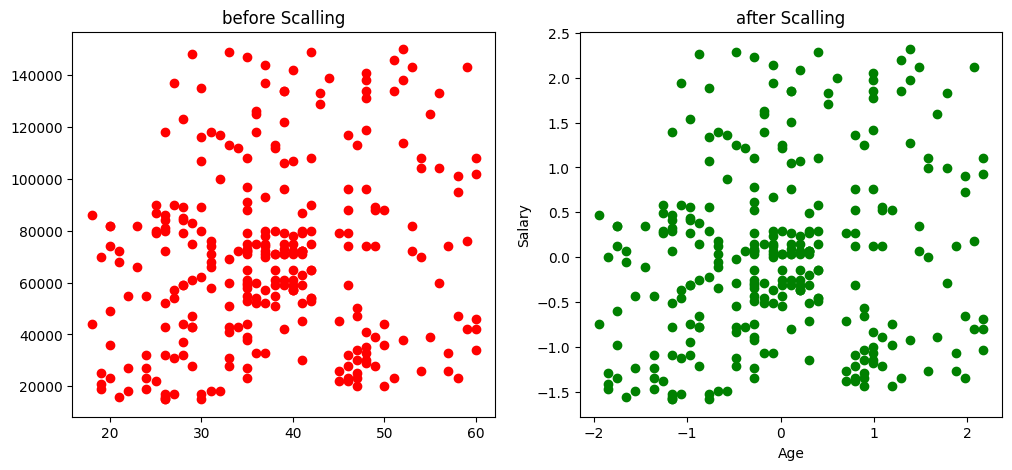

In [955]:
# Effect of Scaling

fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.scatter(X_train["Age"],X_train["EstimatedSalary"],color = "red")
plt.xlabel("Age")
plt.ylabel("Salary")
ax1.set_title("before Scalling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color = "g")
plt.xlabel("Age")
plt.ylabel("Salary")
ax2.set_title("after Scalling")
plt.show()

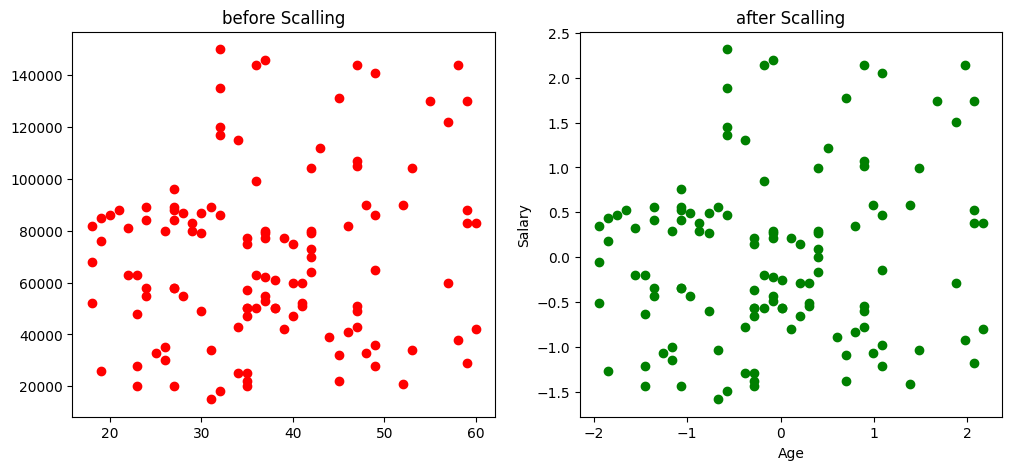

In [956]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))
ax1.scatter(X_test["Age"],X_test["EstimatedSalary"],color = "red")
plt.xlabel("Age")
plt.ylabel("Salary")
ax1.set_title("before Scalling")
ax2.scatter(X_test_scaled["Age"],X_test_scaled["EstimatedSalary"],color = "g")
plt.xlabel("Age")
plt.ylabel("Salary")
ax2.set_title("after Scalling")
plt.show()

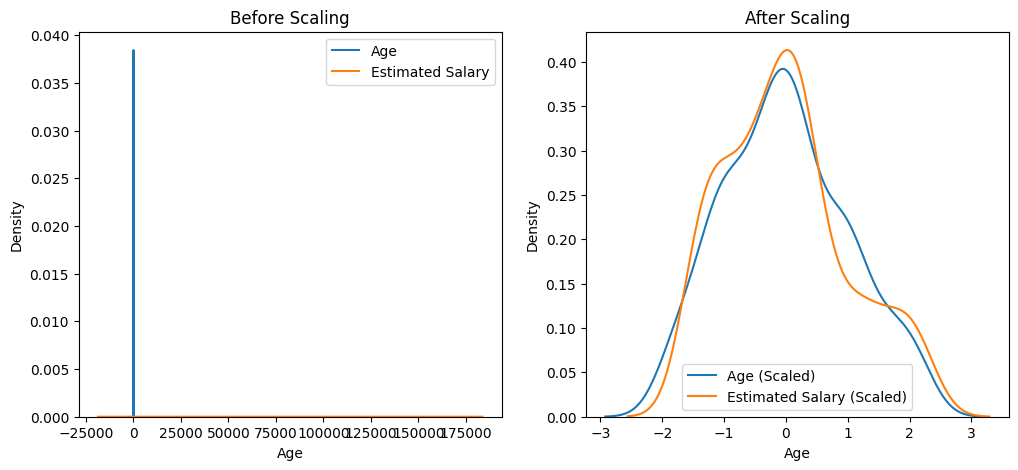

In [957]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1, label="Age")
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1, label="Estimated Salary")
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2, label="Age (Scaled)")
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2, label="Estimated Salary (Scaled)")
ax2.legend()

plt.show()




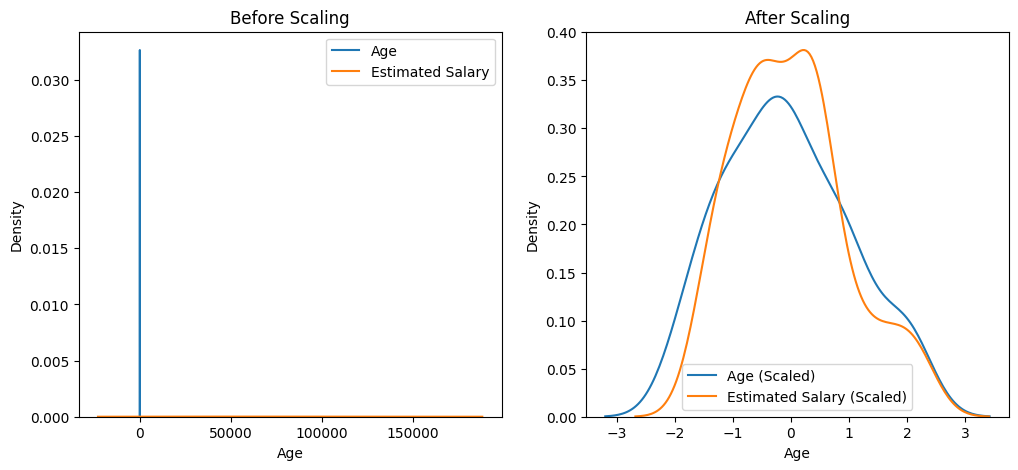

In [958]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_test["Age"], ax=ax1, label="Age")
sns.kdeplot(X_test["EstimatedSalary"], ax=ax1, label="Estimated Salary")
ax1.legend()

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_test_scaled["Age"], ax=ax2, label="Age (Scaled)")
sns.kdeplot(X_test_scaled["EstimatedSalary"], ax=ax2, label="Estimated Salary (Scaled)")
ax2.legend()

plt.show()

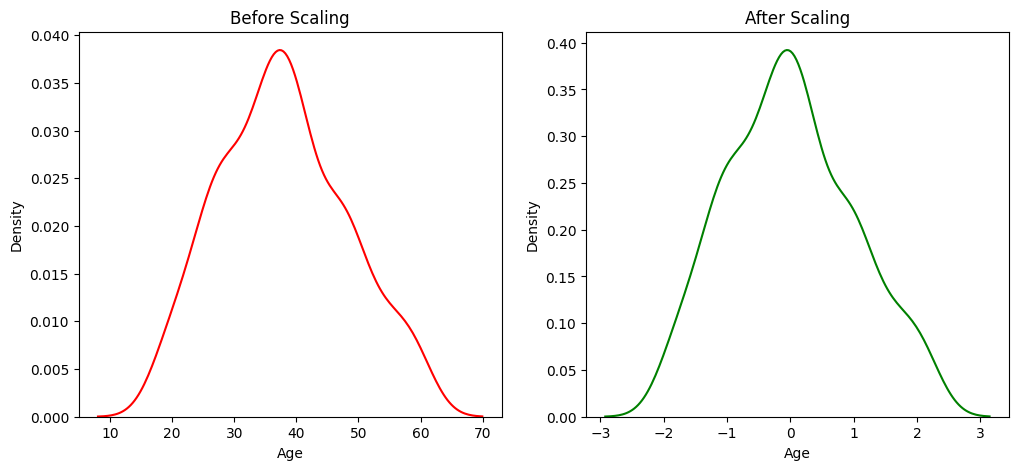

In [959]:
# comprision of distribution
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"],ax = ax1,color="r")
# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"],ax = ax2,color="g")
plt.show()



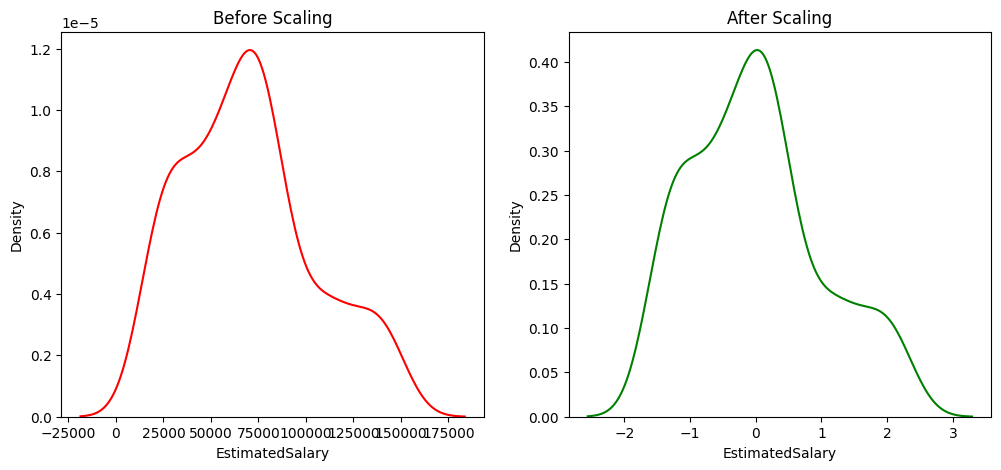

In [960]:
# comprision of distribution
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["EstimatedSalary"],ax = ax1,color="r")
# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["EstimatedSalary"],ax = ax2,color="g")
plt.show()

In [985]:
# Logistic_model

log = LogisticRegression()
log_scaled = LogisticRegression()

In [986]:
log.fit(X_train,y_train)
log_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [987]:
y_pred = log.predict(X_test)


In [988]:
Y_pred_scaled = log_scaled.predict(X_test_scaled)


In [989]:
print("Accuracy_score before scaling",accuracy_score(y_test, y_pred))
print("Accuracy_score After Scaling",accuracy_score(y_test, Y_pred_scaled))

Accuracy_score before scaling 0.875
Accuracy_score After Scaling 0.8666666666666667


In [990]:
# DECIGiON TREE

dt = DecisionTreeClassifier()
dt_Scaled = DecisionTreeClassifier()

In [982]:
dt.fit(X_train,y_train)
dt_Scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [983]:
y_preddt = dt.predict(X_test)
y_preddt_scaled = dt_Scaled.predict(X_test_scaled)

In [984]:
print("Actual accuracy score before scaling",accuracy_score(y_test,y_preddt))
print("scaled accuracy score after scaling ",accuracy_score(y_test,y_preddt_scaled))

Actual accuracy score before scaling 0.875
scaled accuracy score after scaling  0.875


In [992]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model_scaled = RandomForestClassifier(n_estimators=100, random_state=42)

In [993]:
model.fit(X_train,y_train)
model_scaled.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [994]:
y_predRF = model.predict(X_test)
y_predRF_scaled = model_scaled.predict(X_test_scaled )

In [995]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predRF))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predRF_scaled))

Actual Accoracy before scaling 0.9166666666666666
scaled Accuracy after scaling  0.9166666666666666


In [996]:
knnmodel = KNeighborsClassifier(n_neighbors=5)
knnmodel_scaled = KNeighborsClassifier(n_neighbors=5)


In [998]:
knnmodel.fit(X_train,y_train)
knnmodel_scaled.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [999]:
y_predknn = knnmodel.predict(X_test)
y_predknn_scaled = knnmodel_scaled.predict(X_test_scaled )

In [1000]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predknn))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predknn_scaled))

Actual Accoracy before scaling 0.825
scaled Accuracy after scaling  0.9166666666666666


In [1001]:
SVM1 = SVC()
SVM1_scaled = SVC()

In [1003]:
SVM1.fit(X_train,y_train)
SVM1_scaled.fit(X_train_scaled,y_train)

SVC()

In [1005]:
y_predSVM = SVM1.predict(X_test)
y_predSVM_scaled = SVM1_scaled.predict(X_test_scaled)

In [1006]:
print("Actual Accoracy before scaling",accuracy_score(y_test,y_predSVM))
print("scaled Accuracy after scaling ",accuracy_score(y_test,y_predSVM_scaled))

Actual Accoracy before scaling 0.7916666666666666
scaled Accuracy after scaling  0.9083333333333333
